# 🚄 Shinkansen Passenger Satisfaction Prediction

## Project Overview

This capstone project develops a machine-learning model to predict whether a passenger was satisfied with their overall experience on the Shinkansen Bullet Train.

**Target variable:** `Overall_Experience`

- `1` — Satisfied
- `0` — Not satisfied

The final solution uses a five-fold CatBoost ensemble and achieved:

- **Mean 5-fold cross-validation accuracy:** 95.825%
- **Leaderboard accuracy:** 95.82327%
- **Leaderboard rank at submission:** 15

## 1. Business Context

Passenger satisfaction is an important performance indicator for transportation providers. A positive travel experience can improve loyalty, repeat usage, brand perception, and service adoption. Dissatisfied passengers may switch to alternatives and negatively affect public perception.

The Shinkansen serves passengers with different demographic profiles, travel purposes, classes, journey conditions, and service expectations. Predicting satisfaction can help identify the strongest experience drivers and support targeted service improvements.

## 2. Business Objective

The primary objective is to build an accurate binary-classification model that predicts passenger satisfaction using:

- Passenger characteristics
- Travel and journey attributes
- Post-service survey responses

A secondary objective is to identify the factors that contribute most strongly to the model's predictions and translate them into practical business recommendations.

## 3. Problem Definition

This is a supervised binary-classification problem.

The training data contains known labels for `Overall_Experience`. The test data contains the same predictor variables without the target. The trained model is used to generate one prediction for every passenger in the test set.

The competition evaluation metric is **accuracy**:

\[
	ext{Accuracy} =
rac{	ext{Number of correct predictions}}
{	ext{Total number of predictions}}
\]

## 4. Dataset Description

The project uses two raw data sources:

1. **Travel data** — passenger and journey-related attributes
2. **Survey data** — passenger ratings of the post-service experience

Training and test files are supplied separately. Travel and survey data are merged using the common `ID` field.

> The raw competition data is not included in the GitHub repository. Place the four CSV files in the local `data/` directory before running this notebook.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install CatBoost only if it is not already available.
# In Colab, uncomment the next line when needed:
# !pip install catboost -q

In [7]:
!pip install catboost -q
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 5. Project Paths

In [8]:
# This setup works when the notebook is run from the repository root
# or from the notebooks/ directory.

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"
SUBMISSION_DIR = PROJECT_DIR / "submissions"

for directory in [MODEL_DIR, REPORT_DIR, SUBMISSION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)

Project directory: /content
Data directory: /content/data


## 6. Load the Raw Data

In [15]:

DATA_DIR = Path ("/content/drive/MyDrive/Data_Science_2026/Project/Hackathon/DATA")
def find_file(directory: Path, candidates: list[str]) -> Path:
    """Return the first matching file from a list of possible names."""
    for name in candidates:
        path = directory / name
        if path.exists():
            return path
    raise FileNotFoundError(
        f"None of these files were found in {directory}: {candidates}"
    )


travel_train_path = find_file(
    DATA_DIR,
    [
        "Traveldata_train.csv",
        "Traveldata_train_(2).csv",
        "Travel_Data_train.csv",
    ],
)

survey_train_path = find_file(
    DATA_DIR,
    [
        "Surveydata_train.csv",
        "Surveydata_train_(2).csv",
        "Survey_Data_train.csv",
    ],
)

travel_test_path = find_file(
    DATA_DIR,
    [
        "Traveldata_test.csv",
        "Traveldata_test_(2).csv",
        "Travel_Data_test.csv",
    ],
)

survey_test_path = find_file(
    DATA_DIR,
    [
        "Surveydata_test.csv",
        "Surveydata_test_(2).csv",
        "Survey_Data_test.csv",
    ],
)

travel_train = pd.read_csv(travel_train_path)
survey_train = pd.read_csv(survey_train_path)
travel_test = pd.read_csv(travel_test_path)
survey_test = pd.read_csv(survey_test_path)

print("Travel train:", travel_train.shape)
print("Survey train:", survey_train.shape)
print("Travel test:", travel_test.shape)
print("Survey test:", survey_test.shape)

Travel train: (94379, 9)
Survey train: (94379, 17)
Travel test: (35602, 9)
Survey test: (35602, 16)


## 7. Merge and Validate the Data

In [16]:
train_df = travel_train.merge(
    survey_train,
    on="ID",
    how="inner",
    validate="one_to_one",
)

test_df = travel_test.merge(
    survey_test,
    on="ID",
    how="inner",
    validate="one_to_one",
)

print("Merged train:", train_df.shape)
print("Merged test:", test_df.shape)

assert "Overall_Experience" in train_df.columns
assert "Overall_Experience" not in test_df.columns
assert train_df["ID"].is_unique
assert test_df["ID"].is_unique

Merged train: (94379, 25)
Merged test: (35602, 24)


In [17]:
display(train_df.head())
display(train_df.dtypes.to_frame("dtype"))

,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


,dtype
ID,int64
Gender,object
Customer_Type,object
Age,float64
Type_Travel,object
Travel_Class,object
Travel_Distance,int64
Departure_Delay_in_Mins,float64
Arrival_Delay_in_Mins,float64
Overall_Experience,int64


## 8. Data Quality Checks

In [18]:
quality_summary = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "missing_count": train_df.isna().sum(),
    "missing_pct": (train_df.isna().mean() * 100).round(2),
    "unique_values": train_df.nunique(dropna=False),
}).sort_values("missing_pct", ascending=False)

display(quality_summary)

,dtype,missing_count,missing_pct,unique_values
Type_Travel,object,9226,9.78,3
Customer_Type,object,8951,9.48,3
Arrival_Time_Convenient,object,8930,9.46,7
Catering,object,8741,9.26,7
Onboard_Service,object,7601,8.05,7
Arrival_Delay_in_Mins,float64,357,0.38,435
Baggage_Handling,object,142,0.15,6
Legroom,object,90,0.10,7
Online_Support,object,91,0.10,7
CheckIn_Service,object,77,0.08,7


In [19]:
print("Duplicate training rows:", train_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())
print("Missing target values:", train_df["Overall_Experience"].isna().sum())
print("Target values:", sorted(train_df["Overall_Experience"].dropna().unique()))

Duplicate training rows: 0
Duplicate test rows: 0
Missing target values: 0
Target values: [np.int64(0), np.int64(1)]


## 9. Exploratory Data Analysis

,count
Overall_Experience,
Not satisfied,42786
Satisfied,51593


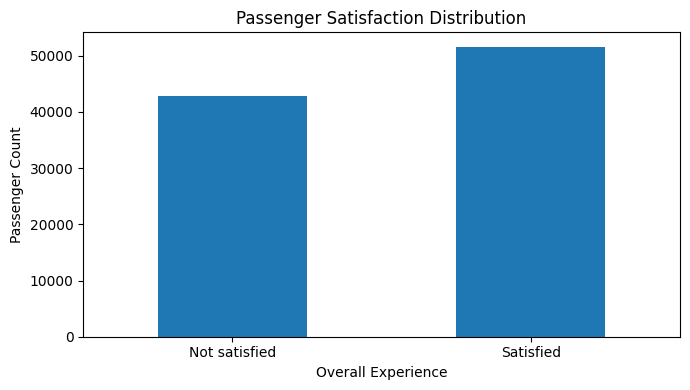

In [20]:
target_distribution = (
    train_df["Overall_Experience"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not satisfied", 1: "Satisfied"})
)

display(target_distribution.to_frame("count"))

plt.figure(figsize=(7, 4))
target_distribution.plot(kind="bar")
plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Overall Experience")
plt.ylabel("Passenger Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
numeric_columns = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_columns = [
    col for col in numeric_columns
    if col not in ["ID", "Overall_Experience"]
]

if numeric_columns:
    display(train_df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,94346.0,39.419647,15.116632,7.0,27.0,40.0,51.0,85.0
Travel_Distance,94379.0,1978.888185,1027.961019,50.0,1359.0,1923.0,2538.0,6951.0
Departure_Delay_in_Mins,94322.0,14.647092,38.138781,0.0,0.0,0.0,12.0,1592.0
Arrival_Delay_in_Mins,94022.0,15.005222,38.439409,0.0,0.0,0.0,13.0,1584.0


## 10. Data Preparation

CatBoost can work directly with categorical features. Missing categorical values are represented using the explicit label `"Missing"`. Numeric missing values are retained because CatBoost handles them natively.

In [22]:
TARGET = "Overall_Experience"
ID_COLUMN = "ID"

test_ids = test_df[ID_COLUMN].copy()

X = train_df.drop(columns=[TARGET, ID_COLUMN]).copy()
y = train_df[TARGET].astype(int).copy()
X_test = test_df.drop(columns=[ID_COLUMN]).copy()

assert list(X.columns) == list(X_test.columns)

categorical_columns = (
    X.select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

for col in categorical_columns:
    X[col] = X[col].astype("string").fillna("Missing").astype(str)
    X_test[col] = X_test[col].astype("string").fillna("Missing").astype(str)

print("Training features:", X.shape)
print("Test features:", X_test.shape)
print("Categorical features:", len(categorical_columns))

Training features: (94379, 23)
Test features: (35602, 23)
Categorical features: 19


## 11. Single-Split Baseline

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

baseline_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    allow_writing_files=False,
    thread_count=-1,
    verbose=False,
)

baseline_model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50,
    verbose=100,
)

valid_predictions = baseline_model.predict(X_valid).astype(int).ravel()
valid_accuracy = accuracy_score(y_valid, valid_predictions)

print(f"Validation accuracy: {valid_accuracy:.5f}")
print("Best iteration:", baseline_model.get_best_iteration())
print(classification_report(y_valid, valid_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_valid, valid_predictions))

0:	learn: 0.8421917	test: 0.8408031	best: 0.8408031 (0)	total: 892ms	remaining: 14m 51s
100:	learn: 0.9521211	test: 0.9472346	best: 0.9473405 (99)	total: 57.6s	remaining: 8m 33s
200:	learn: 0.9606903	test: 0.9522145	best: 0.9522674 (199)	total: 1m 55s	remaining: 7m 39s
300:	learn: 0.9645974	test: 0.9550223	best: 0.9550752 (291)	total: 3m	remaining: 6m 59s
400:	learn: 0.9671271	test: 0.9560288	best: 0.9561348 (386)	total: 3m 58s	remaining: 5m 55s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9561347743
bestIteration = 386

Shrink model to first 387 iterations.
Validation accuracy: 0.95613
Best iteration: 386
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8557
           1       0.97      0.95      0.96     10319

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876

Confusion matrix:
[[8216  341]
 [ 48

## 12. Stratified Five-Fold Cross-Validation

The final solution uses five stratified folds. Each fold model is saved immediately so completed training does not need to be repeated after a notebook restart.

In [24]:
CV_DIR = MODEL_DIR / "baseline_catboost_cv"
CV_DIR.mkdir(parents=True, exist_ok=True)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

fold_scores = []
best_iterations = []
oof_probabilities = np.zeros(len(X), dtype=float)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print("\n" + "=" * 60)
    print(f"BASELINE CATBOOST — FOLD {fold}/5")
    print("=" * 60)

    model_path = CV_DIR / f"catboost_fold_{fold}.cbm"

    X_fold_train = X.iloc[train_idx].copy()
    X_fold_valid = X.iloc[valid_idx].copy()
    y_fold_train = y.iloc[train_idx].copy()
    y_fold_valid = y.iloc[valid_idx].copy()

    model = CatBoostClassifier()

    if model_path.exists():
        print("Loading saved fold model:", model_path.name)
        model.load_model(str(model_path))
    else:
        start_time = time.time()

        model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=8,
            loss_function="Logloss",
            eval_metric="Accuracy",
            random_seed=42 + fold,
            allow_writing_files=False,
            thread_count=-1,
            verbose=False,
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_columns,
            eval_set=(X_fold_valid, y_fold_valid),
            early_stopping_rounds=50,
            verbose=100,
        )

        model.save_model(str(model_path))
        print(f"Training time: {(time.time() - start_time) / 60:.2f} minutes")

    fold_probabilities = model.predict_proba(X_fold_valid)[:, 1]
    oof_probabilities[valid_idx] = fold_probabilities

    fold_predictions = (fold_probabilities >= 0.50).astype(int)
    fold_accuracy = accuracy_score(y_fold_valid, fold_predictions)

    fold_scores.append(fold_accuracy)
    best_iterations.append(model.get_best_iteration())

    np.save(CV_DIR / "fold_scores.npy", np.array(fold_scores))
    np.save(CV_DIR / "best_iterations.npy", np.array(best_iterations))
    np.save(CV_DIR / "oof_probabilities.npy", oof_probabilities)

    print(f"Fold {fold} accuracy: {fold_accuracy:.5f}")

print("\nFold scores:", np.round(fold_scores, 5))
print(f"Mean CV accuracy: {np.mean(fold_scores):.5f}")
print(f"CV standard deviation: {np.std(fold_scores):.5f}")


BASELINE CATBOOST — FOLD 1/5
0:	learn: 0.8468008	test: 0.8452003	best: 0.8452003 (0)	total: 452ms	remaining: 7m 31s
100:	learn: 0.9533661	test: 0.9464399	best: 0.9465989 (98)	total: 60s	remaining: 8m 53s
200:	learn: 0.9608890	test: 0.9523734	best: 0.9524793 (198)	total: 1m 58s	remaining: 7m 50s
300:	learn: 0.9651140	test: 0.9549163	best: 0.9549163 (300)	total: 2m 57s	remaining: 6m 51s
400:	learn: 0.9675774	test: 0.9553931	best: 0.9555520 (385)	total: 3m 54s	remaining: 5m 50s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9559758423
bestIteration = 444

Shrink model to first 445 iterations.
Training time: 4.86 minutes
Fold 1 accuracy: 0.95598

BASELINE CATBOOST — FOLD 2/5
0:	learn: 0.8473306	test: 0.8519814	best: 0.8519814 (0)	total: 426ms	remaining: 7m 6s
100:	learn: 0.9516311	test: 0.9505192	best: 0.9505192 (100)	total: 56.7s	remaining: 8m 24s
200:	learn: 0.9605976	test: 0.9573003	best: 0.9573003 (200)	total: 1m 57s	remaining: 7m 45s
300:	learn: 0.9650875	test: 0

### Recorded Cross-Validation Result

The final baseline CatBoost model achieved:

- **Mean CV accuracy:** `0.95825`
- **CV standard deviation:** approximately `0.00134`

The low standard deviation indicated stable performance across folds.

## 13. Feature-Engineering Experiments

In [25]:
experiment_results = pd.DataFrame({
    "Experiment": [
        "Baseline CatBoost — 5-fold CV",
        "Experiment 2 — 5-fold CV",
        "Experiment 3 — validation split",
        "Experiment 4 — validation split",
    ],
    "Accuracy": [
        0.95825,
        0.95787,
        0.95486,
        0.95656,
    ],
}).sort_values("Accuracy", ascending=False)

display(experiment_results)

,Experiment,Accuracy
0,Baseline CatBoost — 5-fold CV,0.95825
1,Experiment 2 — 5-fold CV,0.95787
3,Experiment 4 — validation split,0.95656
2,Experiment 3 — validation split,0.95486


Experiments included missing-value counts, grouped numerical variables, ordinal survey scores, aggregate service ratings, and selected interaction features.

Although some engineered features produced small improvements on one validation split, they did not outperform the original feature set under cross-validation. The simpler baseline was therefore selected as the final model.

## 14. Final Model Selection

The **five-fold baseline CatBoost ensemble** was selected because it achieved the strongest cross-validation accuracy while retaining a simpler and more stable feature representation.

Final configuration:

- Algorithm: `CatBoostClassifier`
- Number of folds: 5
- Learning rate: 0.05
- Tree depth: 8
- Early stopping: 50 rounds
- Ensemble method: mean predicted probability
- Classification threshold: 0.50

## 15. Generate Final Test Predictions

In [26]:
baseline_models = []

for fold in range(1, 6):
    model_path = CV_DIR / f"catboost_fold_{fold}.cbm"

    if not model_path.exists():
        raise FileNotFoundError(
            f"Missing {model_path.name}. Run the five-fold CV cell first."
        )

    model = CatBoostClassifier()
    model.load_model(str(model_path))
    baseline_models.append(model)

print("Loaded models:", len(baseline_models))

Loaded models: 5


In [27]:
test_probabilities_by_fold = np.column_stack([
    model.predict_proba(X_test)[:, 1]
    for model in baseline_models
])

ensemble_probabilities = test_probabilities_by_fold.mean(axis=1)
final_predictions = (ensemble_probabilities >= 0.50).astype(int)

print(pd.Series(final_predictions).value_counts())
print(pd.Series(final_predictions).value_counts(normalize=True).round(4))

1    19198
0    16404
Name: count, dtype: int64
1    0.5392
0    0.4608
Name: proportion, dtype: float64


## 16. Create and Validate the Submission

In [28]:
submission = pd.DataFrame({
    "ID": test_ids,
    "Overall_Experience": final_predictions,
})

assert submission.shape == (35602, 2)
assert list(submission.columns) == ["ID", "Overall_Experience"]
assert submission["ID"].is_unique
assert submission.isna().sum().sum() == 0
assert set(submission["Overall_Experience"].unique()).issubset({0, 1})

submission_path = SUBMISSION_DIR / "final_catboost_5fold_baseline.csv"
submission.to_csv(submission_path, index=False)

np.save(
    SUBMISSION_DIR / "baseline_ensemble_probabilities.npy",
    ensemble_probabilities,
)

print("Submission saved to:", submission_path)
display(submission.head())

Submission saved to: /content/submissions/final_catboost_5fold_baseline.csv


,ID,Overall_Experience
0,99900001,1
1,99900002,1
2,99900003,1
3,99900004,0
4,99900005,1


## 17. Competition Result

The final submission achieved:

- **Leaderboard accuracy:** `0.9582327` (95.82327%)
- **Leaderboard rank at submission:** `15`

The leaderboard score was almost identical to the five-fold cross-validation estimate of 95.825%, demonstrating that the validation design provided a highly reliable estimate of unseen-data performance.

## 18. Feature Importance

In [29]:
all_importances = np.vstack([
    model.get_feature_importance()
    for model in baseline_models
])

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": all_importances.mean(axis=0),
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance_df.to_csv(
    REPORT_DIR / "feature_importance_final.csv",
    index=False,
)

display(feature_importance_df.head(15))

,Feature,Importance
0,Seat_Comfort,22.778939
1,Type_Travel,9.399963
2,Onboard_Entertainment,9.021153
3,Ease_of_Online_Booking,7.249583
4,Travel_Class,6.595554
5,Customer_Type,6.501470
6,Platform_Location,5.238752
7,Gender,4.916776
8,Baggage_Handling,3.485938
9,Arrival_Time_Convenient,3.436386


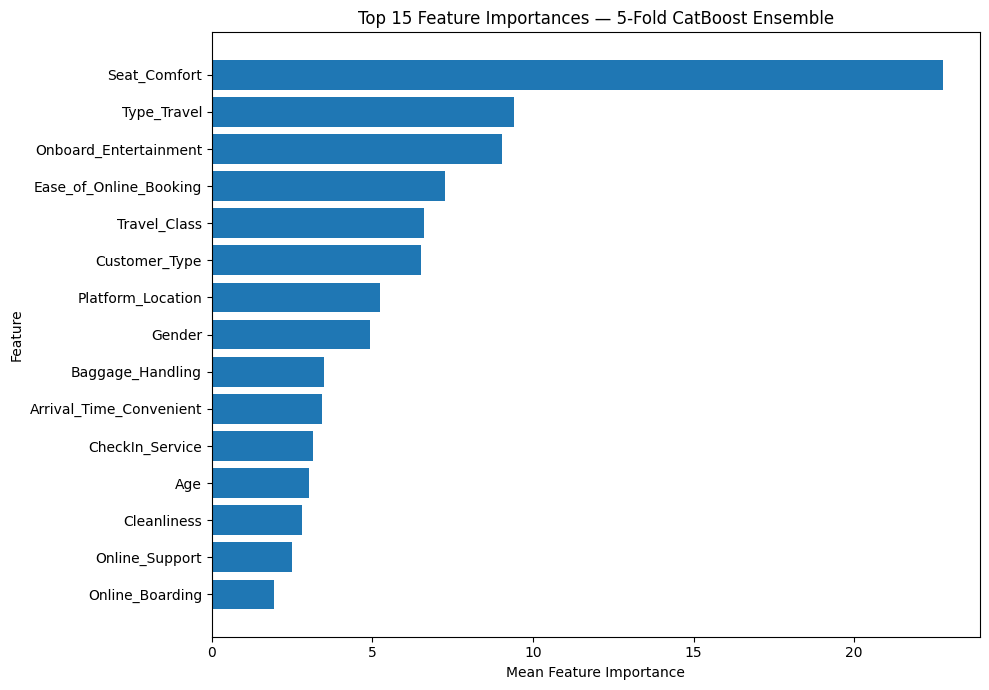

Chart saved to: /content/reports/feature_importance.png


In [30]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)
plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — 5-Fold CatBoost Ensemble")
plt.tight_layout()

feature_chart_path = REPORT_DIR / "feature_importance.png"
plt.savefig(feature_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", feature_chart_path)

### Top Model Drivers

The strongest features were:

1. Seat Comfort
2. Type of Travel
3. Onboard Entertainment
4. Ease of Online Booking
5. Travel Class
6. Customer Type
7. Platform Location
8. Gender
9. Baggage Handling
10. Arrival Time Convenience
11. Check-In Service
12. Age
13. Cleanliness
14. Online Support
15. Online Boarding

`Seat_Comfort` was the most influential feature by a substantial margin.

> Feature importance measures contribution to predictions. It does not establish direction or causality.

## 19. Business Insights

### Seat comfort is the strongest predictor

Physical comfort appears central to the overall passenger experience. Seating quality, ergonomics, spacing, and cushioning should be treated as priority service indicators.

### Passenger expectations vary by travel context

`Type_Travel`, `Travel_Class`, and `Customer_Type` were highly influential. Satisfaction strategies should therefore be segmented rather than applied uniformly.

### The experience starts before boarding

`Ease_of_Online_Booking`, `Online_Support`, and `Online_Boarding` demonstrate that the digital journey contributes to overall satisfaction.

### The end-to-end journey matters

Platform location, baggage handling, check-in service, cleanliness, entertainment, and arrival convenience all influenced model predictions.

## 20. Business Recommendations

1. **Prioritize seat comfort** through regular quality monitoring and targeted upgrades.
2. **Segment passengers** by travel purpose, customer type, and travel class.
3. **Improve digital services**, especially booking, support, and online boarding.
4. **Maintain consistent onboard standards** for entertainment, cleanliness, and baggage handling.
5. **Improve station and platform convenience** through accessibility, navigation, and passenger information.
6. **Track satisfaction by service touchpoint** to identify where interventions can have the greatest impact.

## 21. Conclusion

This project developed an end-to-end machine-learning solution for predicting passenger satisfaction with the Shinkansen travel experience.

A five-fold CatBoost ensemble achieved approximately **95.83% cross-validation accuracy** and **95.82327% leaderboard accuracy**. The near-identical results demonstrate strong generalization.

Feature-engineering experiments did not consistently improve on the original feature set, so the simpler baseline was retained. Model interpretation identified seat comfort, travel purpose, onboard entertainment, online booking, travel class, customer type, and platform location as the strongest satisfaction drivers.

## 22. Reproducibility Notes

- Place the four raw competition CSV files in `data/`.
- Run the notebook from top to bottom for a new training run.
- Saved fold models are reused automatically when available.
- The raw dataset and trained binary models are intentionally excluded from the public repository.
- No private Google Drive paths, credentials, failed cells, or traceback outputs are included in this cleaned notebook.

In [31]:
! jupyter nbconvert --to html  "/content/drive/MyDrive/Data_Science_2026/Project/Hackathon/shinkansen_travel_experience_clean.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Data_Science_2026/Project/Hackathon/shinkansen_travel_experience_clean.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 512171 bytes to /content/drive/MyDrive/Data_Science_2026/Project/Hackathon/shinkansen_travel_experience_clean.html
